
Processing Ast...
  Overlap genes: 56

Processing Mic...
  Overlap genes: 55

Processing In...
  Overlap genes: 17

Processing Oli...
  Overlap genes: 102

Processing Opc...
  Overlap genes: 23

Processing Ex...
  Overlap genes: 24


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"]

<Figure size 1000x600 with 0 Axes>

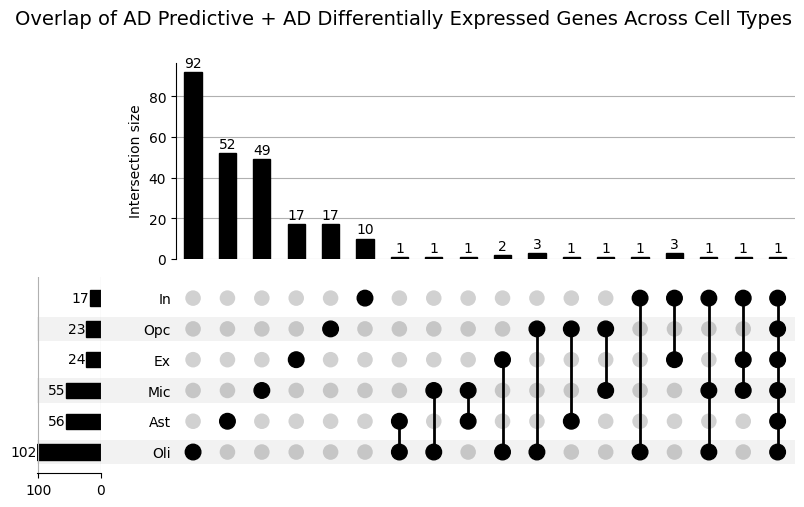


 UpSet plot saved to: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/upset_overlap_plot.png


In [11]:
# upset plot
import os
import pandas as pd
import joblib
from collections import defaultdict
from matplotlib import pyplot as plt
from upsetplot import from_contents, UpSet
# reran aug 11th

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
de_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Fixed/"
out_fig_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/upset_overlap_plot.png"

# === Cell types ===
cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]

# === DE result files ===
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Initialize dictionaries to store gene sets ===
predictive_de_overlap_dict = {}

# === Loop through each cell type ===
for cell_type_short in cell_types:
    print(f"\nProcessing {cell_type_short}...")

    # --- Predictive genes from model ---
    gene_presence = defaultdict(int)
    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type_short, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue
        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_
        for gene, imp in zip(feature_names, importances):
            if imp > 0:
                gene_presence[gene.upper()] += 1
    predictive_genes = {gene for gene, count in gene_presence.items() if count >= 2}

    # --- Differentially expressed genes (p_adj < 0.05 only) ---
    de_path = os.path.join(de_base_dir, de_files[cell_type_short])
    df = pd.read_csv(de_path)
    df = df[df["p_adj"].notnull()]
    df["gene_upper"] = df["gene"].str.upper()

    # de_genes = set(df[df["p_adj"] < 0.05]["gene_upper"])
    de_genes = set(df[(df["p_adj"] < 0.05) & (df["log2FC"].abs() > 0.25)]["gene_upper"])

    # --- Overlap ---
    overlap_genes = predictive_genes & de_genes
    predictive_de_overlap_dict[cell_type_short] = overlap_genes
    print(f"  Overlap genes: {len(overlap_genes)}")

# === Create UpSet plot ===
contents = {k: v for k, v in predictive_de_overlap_dict.items() if len(v) > 0}

upset_data = from_contents(contents)
plt.figure(figsize=(10, 6))
upset = UpSet(upset_data, subset_size='count', show_counts=True, sort_by='degree')
upset.plot()

# === annotate small intersections ===
# find the Axes that has the bar chart

plt.suptitle("Overlap of AD Predictive + AD Differentially Expressed Genes Across Cell Types", fontsize=14)
plt.savefig(out_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n UpSet plot saved to: {out_fig_path}")

In [23]:
import os
import pandas as pd
import joblib
from collections import defaultdict

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
de_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Fixed/"

# === Cell types and DE files ===
cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Calculate percentage overlap ===
for cell_type_short in cell_types:
    # --- Predictive genes ---
    gene_presence = defaultdict(int)
    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type_short, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue
        model = joblib.load(joblib_path)
        for gene, imp in zip(model.feature_names_in_, model.feature_importances_):
            if imp > 0:
                gene_presence[gene.upper()] += 1
    predictive_genes = {g for g, count in gene_presence.items() if count >= 2}

    # --- DEGs ---
    de_path = os.path.join(de_base_dir, de_files[cell_type_short])
    df = pd.read_csv(de_path)
    df = df[df["p_adj"].notnull()]
    # de_genes = set(df[(df["p_adj"] < 0.05) & (df["log2FC"].abs() > 0.25)]["gene_upper"])
    # de_genes = set(df.loc[df["p_adj"] < 0.05, "gene"].str.upper())
    df["gene_upper"] = df["gene"].str.upper()
    de_genes = set(df[(df["p_adj"] < 0.05) & (df["log2FC"].abs() > 0.25)]["gene_upper"])

    # --- Percentage overlap ---
    overlap_count = len(predictive_genes & de_genes)
    total_predictive = len(predictive_genes)
    percent_overlap = (overlap_count / total_predictive * 100) if total_predictive > 0 else 0

    print(f"{cell_type_short}: {percent_overlap:.2f}% of predictive genes were DEGs "
          f"({overlap_count}/{total_predictive})")

Ast: 32.00% of predictive genes were DEGs (56/175)
Mic: 11.80% of predictive genes were DEGs (55/466)
In: 15.74% of predictive genes were DEGs (17/108)
Oli: 16.43% of predictive genes were DEGs (102/621)
Opc: 2.75% of predictive genes were DEGs (23/835)
Ex: 14.81% of predictive genes were DEGs (24/162)


          Down   Up
CellType           
Ast         69  141
Ex         382  699
In         142  110
Mic         61   36
Oli        266  391
Opc         19   28


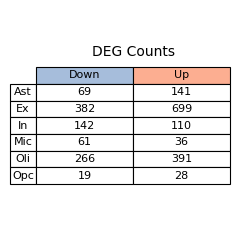

Table figure saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/deg_counts_table_style.png


In [14]:
# deg table
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
# reran aug11th

# === Paths ===
de_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Fixed/"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/"
os.makedirs(out_dir, exist_ok=True)

# === Cell types ===
cell_types = ["Ast", "Ex", "In", "Mic", "Oli", "Opc"]
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === DEG count summary DataFrame (strict cutoff) ===
deg_summary = []

for ct in cell_types:
    df = pd.read_csv(os.path.join(de_base_dir, de_files[ct]))
    df = df[(df["p_adj"] < 0.05) & (abs(df["log2FC"]) > 0.25)]
    up_count = (df["log2FC"] > 0.25).sum()
    down_count = (df["log2FC"] < -0.25).sum()
    deg_summary.append({"CellType": ct, "Down": down_count, "Up": up_count})

deg_summary_df = pd.DataFrame(deg_summary).set_index("CellType")
print(deg_summary_df)

# === Plot table-like figure ===
fig, ax = plt.subplots(figsize=(2.5, 3))
ax.axis('off')

# Convert to string for table
cell_text = deg_summary_df.astype(str).values.tolist()

# Create table
table = ax.table(
    cellText=cell_text,
    rowLabels=deg_summary_df.index,
    colLabels=["Down", "Up"],
    cellLoc='center',
    rowLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)

# Add thin black grid lines and adjust scaling
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0.8)
    cell.set_edgecolor('black')
    cell.set_facecolor('white')

# Shade header cells: row 0
soft_blue = "#a6bddb"   # muted blue
soft_red = "#fcae91"    # muted red

table[(0, 0)].set_facecolor(soft_blue)  # Down
table[(0, 1)].set_facecolor(soft_red)   # Up

# No rotation of headers
for col in range(len(deg_summary_df.columns)):
    header_cell = table[(0, col)]
    header_cell.get_text().set_rotation(0)

# Title "DEGs" centered above
plt.text(0.5, 0.8, "DEG Counts", fontsize=10, ha='center', transform=ax.transAxes)

plt.savefig(os.path.join(out_dir, "deg_counts_table_style.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Table figure saved to {os.path.join(out_dir, 'deg_counts_table_style.png')}")

Astrocytes: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Fixed/overlap_pred_DE_Ast.csv


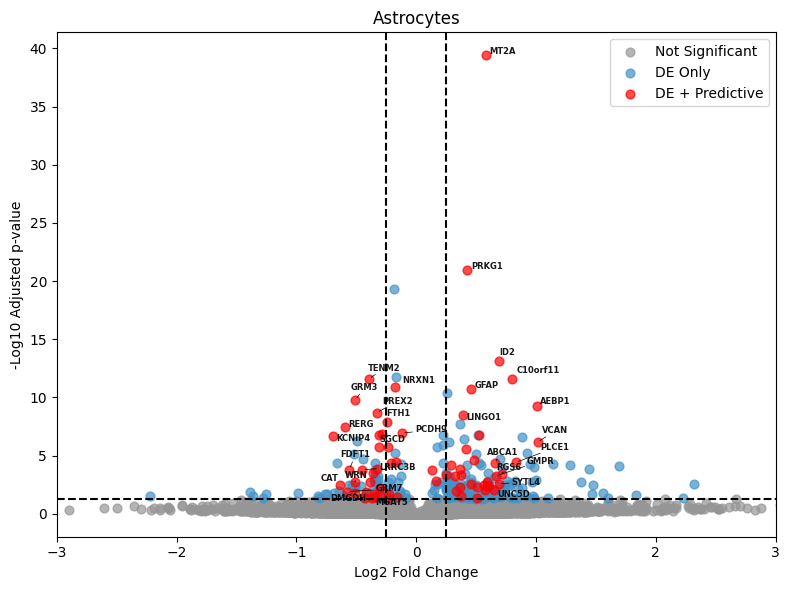

Astrocytes: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/volcano_Ast_pred_marked.png
Microglia: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Fixed/overlap_pred_DE_Mic.csv


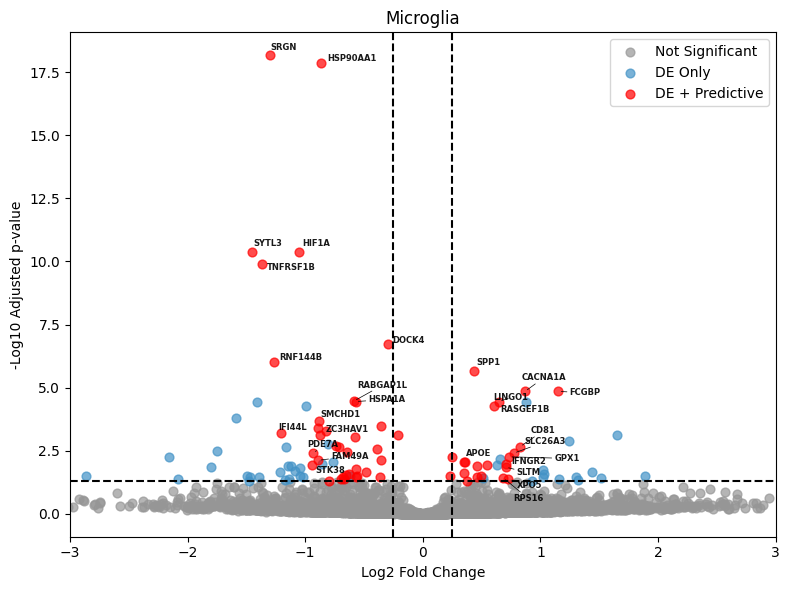

Microglia: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/volcano_Mic_pred_marked.png
Inhibitory Neurons: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Fixed/overlap_pred_DE_In.csv


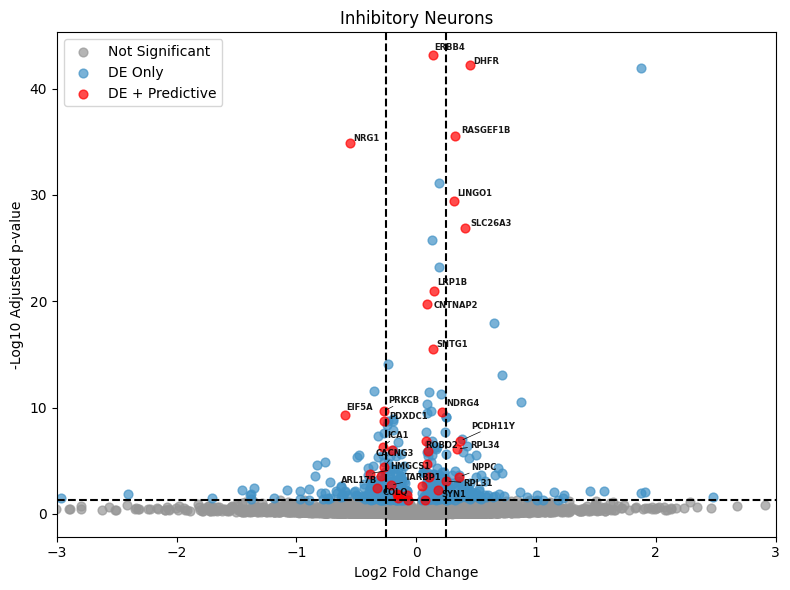

Inhibitory Neurons: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/volcano_In_pred_marked.png
Oligodendrocytes: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Fixed/overlap_pred_DE_Oli.csv


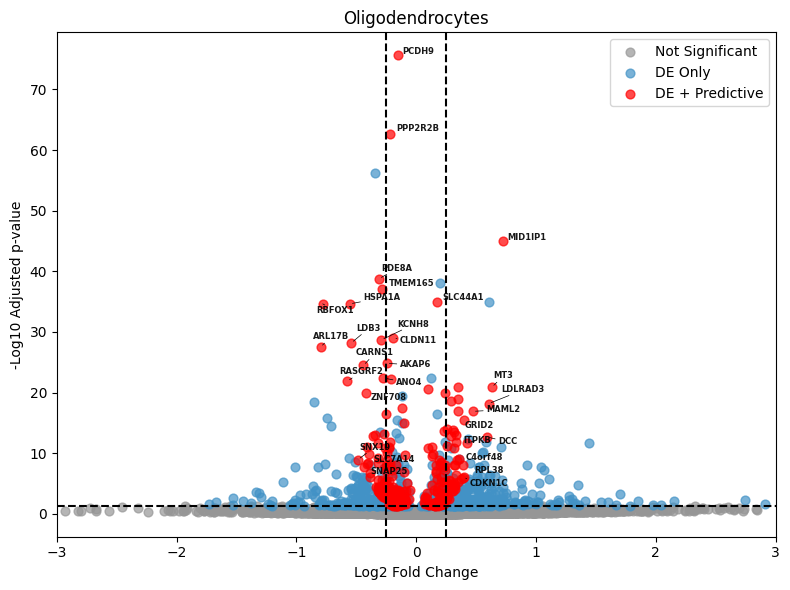

Oligodendrocytes: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/volcano_Oli_pred_marked.png
Oligodendrocyte Progenitor Cells: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Fixed/overlap_pred_DE_Opc.csv


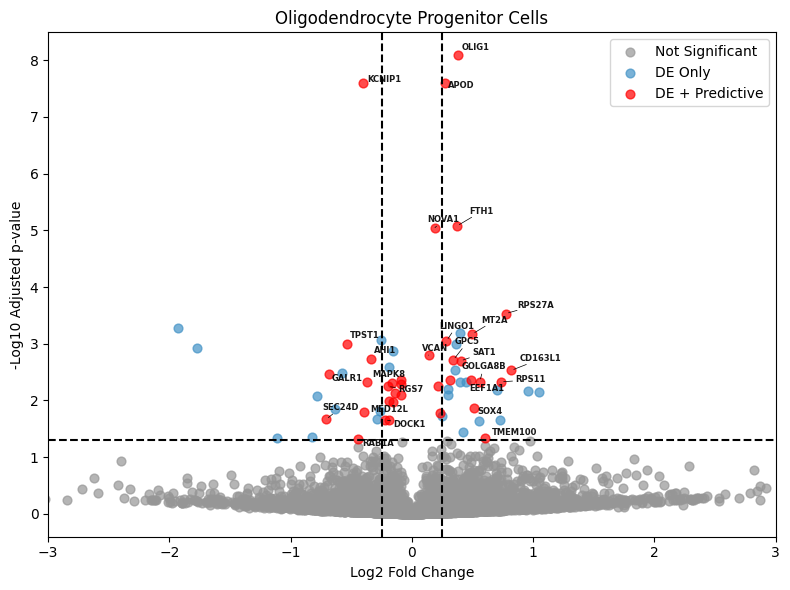

Oligodendrocyte Progenitor Cells: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/volcano_Opc_pred_marked.png
Excitatory Neurons: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Fixed/overlap_pred_DE_Ex.csv


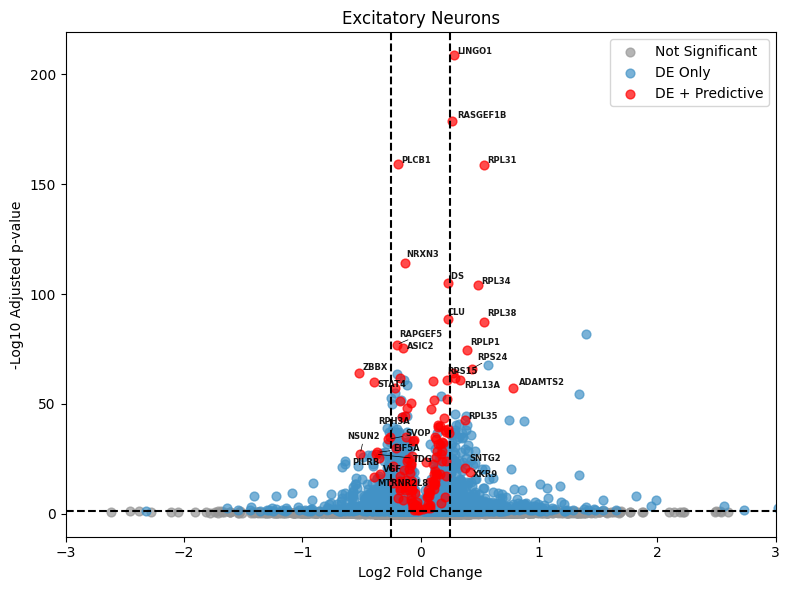

Excitatory Neurons: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/volcano_Ex_pred_marked.png
Overlap CSVs and volcano plots saved for all cell types!


In [21]:
# volcano plots
import os
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from adjustText import adjust_text

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
de_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Fixed"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Overlap_Tables/Fixed/"
fig_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/"
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# === Cell types ===
ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Opc': 'Oligodendrocyte Progenitor Cells',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# === DE result files ===
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Store predictive genes ===
predictive_genes_dict = {}

# === Process each cell type ===
for cell_type_short in cell_types:
    # --- Build predictive genes using your logic ---
    gene_presence = defaultdict(int)
    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type_short, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue
        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_
        for gene, imp in zip(feature_names, importances):
            if imp > 0:
                gene_presence[gene.upper()] += 1
    predictive_genes = {gene for gene, count in gene_presence.items() if count >= 2}
    predictive_genes_dict[cell_type_short] = predictive_genes

    # --- Load DE genes ---
    de_path = os.path.join(de_base_dir, de_files[cell_type_short])
    df = pd.read_csv(de_path)
    df = df[df["p_adj"].notnull() & df["log2FC"].notnull()]
    df["gene_upper"] = df["gene"].str.upper()

    # --- Identify DE genes (FDR adjusted p-values) ---
    de_genes = set(df[df["p_adj"] < 0.05]["gene_upper"])

    # --- Find overlap ---
    overlap_genes = predictive_genes & de_genes

    # --- Save overlap CSV ---
    overlap_df = df[df["gene_upper"].isin(overlap_genes)].copy()
    overlap_df = overlap_df[["gene", "p_adj"]].sort_values("p_adj")
    out_path = os.path.join(out_dir, f"overlap_pred_DE_{cell_type_short}.csv")
    overlap_df.to_csv(out_path, index=False)
    print(f"{ct_labels[cell_type_short]}: Overlap genes saved to {out_path}")

    # === Volcano plot ===
    df["-log10_padj"] = -np.log10(df["p_adj"])
    # Filtering off genes that are more than 20 absolute value log fold away
    df = df[df["log2FC"].abs() <= 20]

    # Thresholds
    logfc_thresh = 0.25
    pval_thresh = 0.05

    # Group assignment
    df["group"] = "Not Significant"
    df.loc[(df["p_adj"] < pval_thresh) & (~df["gene_upper"].isin(predictive_genes)), "group"] = "DE Only"
    df.loc[(df["p_adj"] < pval_thresh) & (df["gene_upper"].isin(predictive_genes)), "group"] = "DE + Predictive"

    # Color map
    color_map = {
    "Not Significant": "#969696",       # medium grey
    "DE Only": "#4292c6",               # medium-deep blue
    "DE + Predictive": "red"         # deep red
    }

    plt.figure(figsize=(8, 6))

    for group, color in color_map.items():
        subset = df[df["group"] == group]
        plt.scatter(subset["log2FC"], subset["-log10_padj"], color=color, alpha=0.7, s=40, label=group)
    df = df[df["log2FC"].between(-3, 3)]

    # xmax = np.ceil(max(abs(df["log2FC"].min()), abs(df["log2FC"].max())) + 0.5)
    # plt.xlim(-xmax, xmax)

    plt.xlim(-3, 3)

    plt.axvline(x=logfc_thresh, color='black', linestyle='--')
    plt.axvline(x=-logfc_thresh, color='black', linestyle='--')
    plt.axhline(y=-np.log10(pval_thresh), color='black', linestyle='--')

    # Label DE + Predictive genes
    label_df = df[df["group"] == "DE + Predictive"]

    top_padj = label_df.nsmallest(15, "p_adj")
    top_up = label_df.nlargest(10, "log2FC")
    top_down = label_df.nsmallest(10, "log2FC")


    # texts = []
    # for _, row in final_label_df.iterrows():
    #     texts.append(plt.text(row["log2FC"], row["-log10_padj"], row["gene"], fontsize=6, fontweight="bold", alpha=0.9))
    
    # (existing code that sets final_label_df)
    final_label_df = pd.concat([top_padj, top_up, top_down]).drop_duplicates(subset="gene_upper")

    if cell_type_short == 'Mic':
        apoe_rows = df[df['gene_upper'] == 'APOE']
        if not apoe_rows.empty:
            final_label_df = pd.concat([final_label_df, apoe_rows]).drop_duplicates(subset="gene_upper")
            # Optional: highlight APOE with a ring so it stands out
            plt.scatter(apoe_rows["log2FC"], apoe_rows["-log10_padj"],
                        s=40, facecolors='none', edgecolors='none', linewidths=1.2, zorder=4)


    # (rest of your labeling code stays the same)
    texts = []
    for _, row in final_label_df.iterrows():
        texts.append(plt.text(row["log2FC"], row["-log10_padj"], row["gene"],
                            fontsize=6, fontweight="bold", alpha=0.9))
    # adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-Log10 Adjusted p-value")
    plt.title(f"{ct_labels[cell_type_short]}")
    plt.legend()
    plt.tight_layout()

    fig_path = os.path.join(fig_dir, f"volcano_{cell_type_short}_pred_marked.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"{ct_labels[cell_type_short]}: Volcano plot saved to {fig_path}")

print("Overlap CSVs and volcano plots saved for all cell types!")

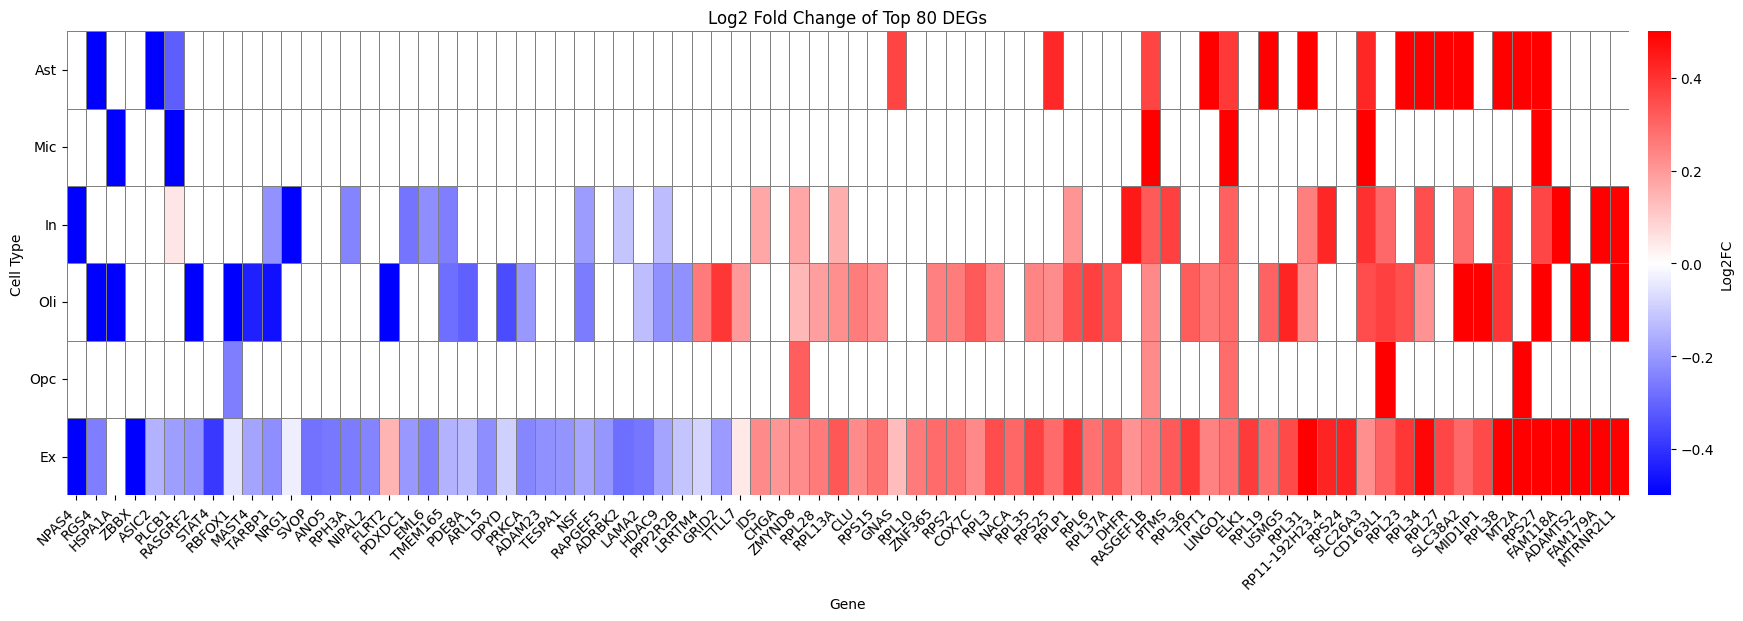

Horizontal heatmap saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/heatmap_top50_genes_columns.png


In [ ]:
# # deg heatmap
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os

# # === Paths ===
# de_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Fixed"
# out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/"
# os.makedirs(out_dir, exist_ok=True)

# # === Cell types ===
# cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]
# de_files = {
#     "Ast": "poisson_DE_results_Ast.csv",
#     "Mic": "poisson_DE_results_Mic.csv",
#     "In": "poisson_DE_results_In.csv",
#     "Oli": "poisson_DE_results_Oli.csv",
#     "Opc": "poisson_DE_results_Opc.csv",
#     "Ex": "poisson_DE_results_Ex.csv"
# }

# # === Collect log2FCs for all genes across cell types ===
# gene_log2fc_dict = {}

# for ct in cell_types:
#     de_path = os.path.join(de_base_dir, de_files[ct])
#     df = pd.read_csv(de_path)
#     df = df[df["p_adj"] < 0.05]
#     for _, row in df.iterrows():
#         gene = row["gene"]
#         if gene not in gene_log2fc_dict:
#             gene_log2fc_dict[gene] = {}
#         gene_log2fc_dict[gene][ct] = row["log2FC"]

# # === Compute overall significance to select top 50 genes ===
# all_dfs = []
# for ct in cell_types:
#     df = pd.read_csv(os.path.join(de_base_dir, de_files[ct]))
#     df = df[df["p_adj"] < 0.05]
#     all_dfs.append(df)
# combined_df = pd.concat(all_dfs)
# # combined_df_grouped = combined_df.groupby("gene")["p_adj"].min().reset_index()
# # top_genes = combined_df_grouped.nsmallest(50, "p_adj")["gene"].tolist()
# # Group by gene and take minimal p_adj
# combined_df_grouped = combined_df.groupby("gene")["p_adj"].min().reset_index()

# # Find genes with log2FC > 0.2 in at least one cell type
# genes_with_large_fc = combined_df.groupby("gene")["log2FC"].apply(lambda x: np.max(np.abs(x)))
# genes_with_large_fc = genes_with_large_fc[genes_with_large_fc > 0.2].index.tolist()

# # Keep only those genes in combined_df_grouped
# filtered_df = combined_df_grouped[combined_df_grouped["gene"].isin(genes_with_large_fc)]

# # Pick top 50 by p_adj from this filtered set
# top_genes = filtered_df.nsmallest(80, "p_adj")["gene"].tolist()

# # === Build heatmap DataFrame ===
# heatmap_df = pd.DataFrame(index=cell_types, columns=top_genes)

# for gene in top_genes:
#     for ct in cell_types:
#         val = gene_log2fc_dict.get(gene, {}).get(ct, np.nan)
#         heatmap_df.loc[ct, gene] = val

# heatmap_df = heatmap_df.astype(float)

# gene_means = heatmap_df.mean(axis=0)
# sorted_genes = gene_means.sort_values().index.tolist()
# heatmap_df = heatmap_df[sorted_genes]

# # === Plot heatmap (genes = columns, cell types = rows) ===
# plt.figure(figsize=(24, 8))  # Wide for many genes
# sns.heatmap(
#     heatmap_df,
#     cmap="bwr",
#     center=0,
#     linewidths=0.5,
#     linecolor='gray',
#     cbar_kws={'label': 'Log2FC', 'pad': 0.01},
#     vmin=-0.5, vmax=0.5  # You can adjust after seeing
# )
# plt.title("Log2 Fold Change of Top 80 DEGs")
# plt.xlabel("Gene")
# plt.xticks(rotation=45, ha='right')
# plt.ylabel("Cell Type")
# plt.yticks(rotation=0)
# plt.subplots_adjust(bottom=0.3)  # Value between 0 and 1; larger = more space

# plt.savefig(os.path.join(out_dir, "heatmap_top80_genes_columns.png"), dpi=300)
# plt.show()

# print(f"Horizontal heatmap saved to {os.path.join(out_dir, 'heatmap_top50_genes_columns.png')}")

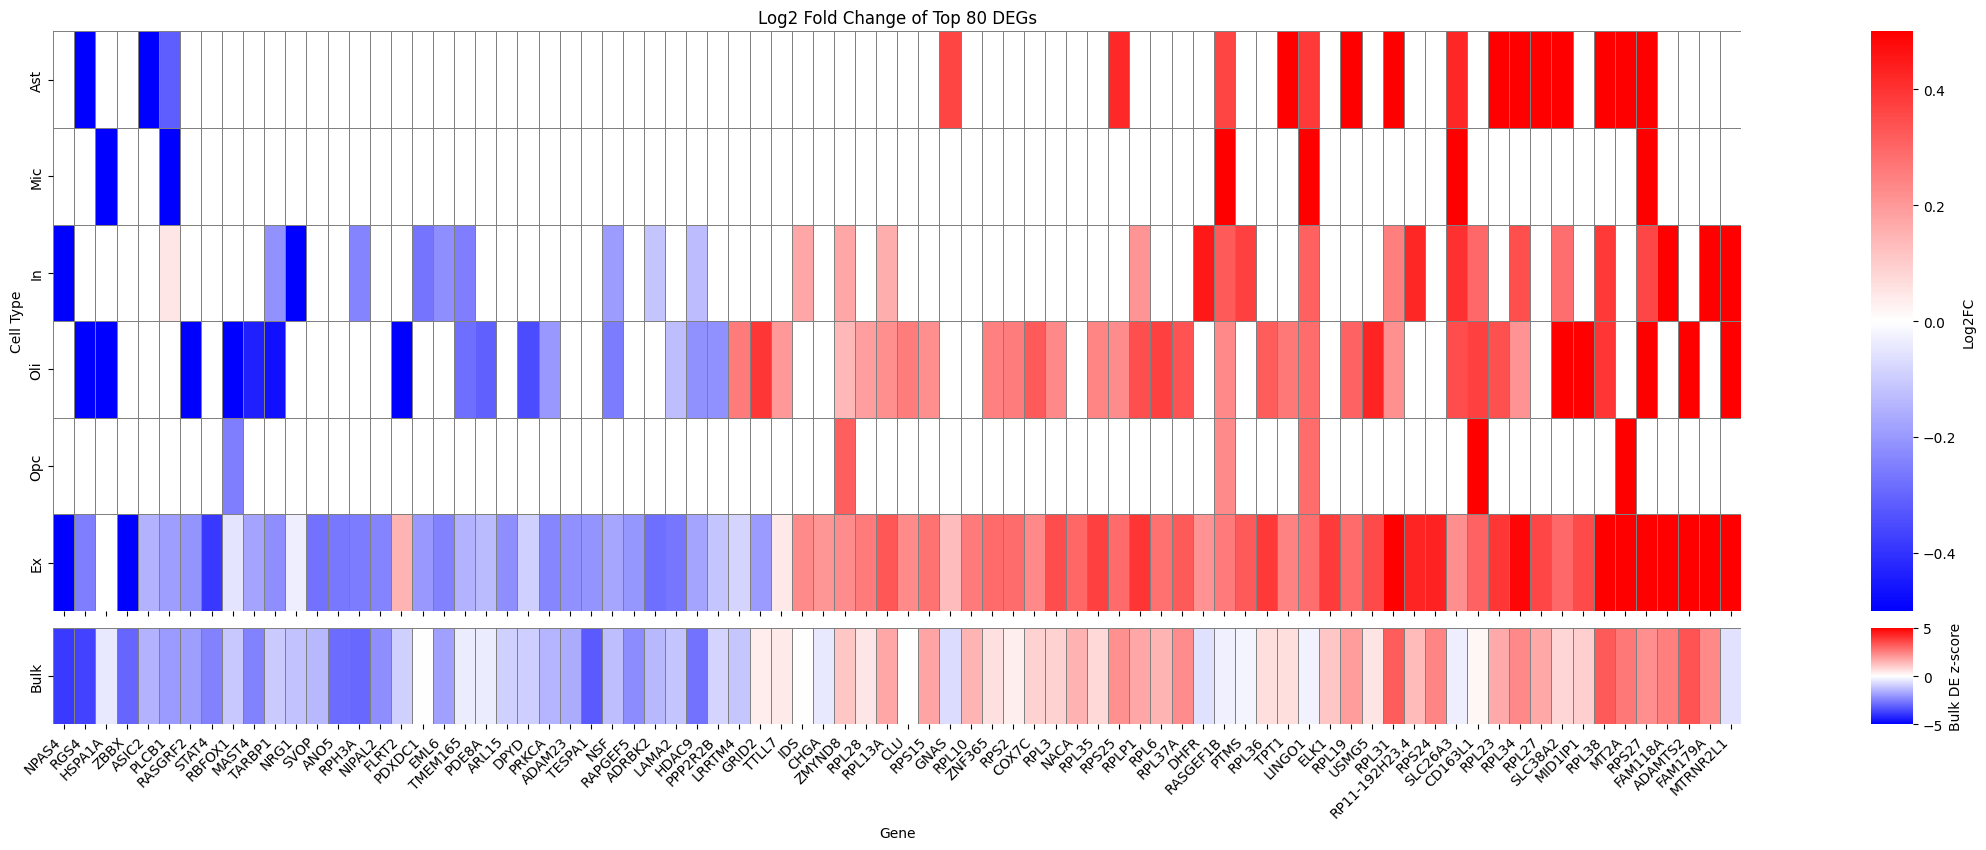

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/heatmap_top80_genes_with_bulk.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import os

# 0) Make sure column names are identical objects on both sides
heatmap_df.columns = pd.Index([str(c).strip() for c in heatmap_df.columns])

bulk_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Bulk/"
z_path = os.path.join(bulk_dir, "zscore_directionality_matrix.csv")
bulk_z = pd.read_csv(z_path)
bulk_z["gene"] = bulk_z["gene"].astype(str).str.strip()

# 1) Build Bulk row in *exact* same order (NaN -> white)
bulk_row = bulk_z.set_index("gene")["Bulk"].reindex(heatmap_df.columns)
bulk_heatmap = pd.DataFrame([bulk_row], index=["Bulk"])

# 2) Combine, then split (columns guaranteed identical)
combined = pd.concat([heatmap_df, bulk_heatmap], axis=0)
top    = combined.iloc[:-1, :]
bottom = combined.iloc[-1:, :]

# 3) Plot with fixed-width colorbar columns (prevents axis width drift)
fig = plt.figure(figsize=(24, 9))
gs = GridSpec(nrows=2, ncols=2, width_ratios=[40, 1], height_ratios=[6, 1], hspace=0.05, wspace=0.15)

ax1  = fig.add_subplot(gs[0, 0])
cax1 = fig.add_subplot(gs[0, 1])   # colorbar for top
ax2  = fig.add_subplot(gs[1, 0], sharex=ax1)
cax2 = fig.add_subplot(gs[1, 1])   # colorbar for bottom

# Top: CT log2FC
sns.heatmap(
    top, ax=ax1,
    cmap="bwr", center=0,
    linewidths=0.5, linecolor="gray",
    cbar=True, cbar_ax=cax1,
    cbar_kws={"label": "Log2FC", "pad": 0.02},
    vmin=-0.5, vmax=0.5
)
ax1.set_title("Log2 Fold Change of Top 80 DEGs")

# ax1.set_title("Cell-type log2FC (Top 80 DEGs)")
ax1.set_ylabel("Cell Type")


# Bottom: Bulk z
sns.heatmap(
    bottom, ax=ax2,
    cmap="bwr", center=0,
    linewidths=0.5, linecolor="gray",
    cbar=True, cbar_ax=cax2,
    cbar_kws={"label": "Bulk DE z-score", "pad": 0.02},
    vmin=-5, vmax=5
)

ax2.set_xlabel("Gene")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
ax2.set_ylabel("")

# Hard-lock x-limits and tick positions to be identical
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(np.arange(len(top.columns)) + 0.5)
ax1.set_xticks(np.arange(len(top.columns)) + 0.5)

ax1.tick_params(axis='x', labelbottom=False)

out_path = os.path.join(out_dir, "heatmap_top80_genes_with_bulk.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

In [22]:
import os
import pandas as pd
import numpy as np

# ==== Paths (edit if needed) ====
de_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/Fixed"
bulk_dir    = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Bulk"
out_dir     = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3"
os.makedirs(out_dir, exist_ok=True)

# Cell types and files (must match your single-cell DE results)
cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In":  "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex":  "poisson_DE_results_Ex.csv",
}

# ==== Load bulk z-scores (directionality reference) ====
bulk_z_path = os.path.join(bulk_dir, "zscore_directionality_matrix.csv")
bulk_df = pd.read_csv(bulk_z_path)
# Ensure clean gene keys
bulk_df["gene"] = bulk_df["gene"].astype(str).str.strip()
bulk_df = bulk_df[["gene", "Bulk"]].dropna(subset=["gene"])

# Sign helper
def sign_series(x):
    # np.sign gives -1, 0, 1; keep that behavior (no thresholds)
    return np.sign(x)

summary_rows = []
per_ct_mismatches = {}  # optional: store mismatched genes per CT

for ct in cell_types:
    de_path = os.path.join(de_base_dir, de_files[ct])
    if not os.path.exists(de_path):
        print(f"[WARN] Missing DE file for {ct}: {de_path}")
        continue

    # Load single-cell DE and filter to DEGs by that CT's adjusted p-value
    de = pd.read_csv(de_path)
    # Expect columns: gene, log2FC, p_adj
    if not {"gene", "log2FC", "p_adj"}.issubset(de.columns):
        raise ValueError(f"DE file for {ct} must contain columns: gene, log2FC, p_adj")

    de["gene"] = de["gene"].astype(str).str.strip()
    degs = de.loc[
    de["p_adj"].notnull() &
    (de["p_adj"] < 0.05) &
    (de["log2FC"].abs() > 0.25),
    ["gene", "log2FC", "p_adj"]].copy()
    # degs = de.loc[de["p_adj"].notnull() & (de["p_adj"] < 0.05), ["gene", "log2FC", "p_adj"]].copy()

    # Merge with bulk z by gene
    merged = degs.merge(bulk_df, on="gene", how="left")
    # Keep only genes that have bulk z available (so direction can be compared)
    merged = merged.loc[merged["Bulk"].notnull()].copy()

    # Compute signs
    merged["sign_sc"]   = sign_series(merged["log2FC"])
    merged["sign_bulk"] = sign_series(merged["Bulk"])
    merged["agree"]     = (merged["sign_sc"] == merged["sign_bulk"])

    n_deg_total   = len(degs)
    n_overlap     = len(merged)
    n_agree       = int(merged["agree"].sum())
    pct_agree     = (n_agree / n_overlap * 100.0) if n_overlap > 0 else np.nan

    # Track mismatches (optional)
    mism = merged.loc[~merged["agree"], ["gene", "log2FC", "Bulk", "p_adj"]].copy()
    per_ct_mismatches[ct] = mism

    summary_rows.append({
        "cell_type": ct,
        "n_singlecell_DEGs": n_deg_total,
        "n_overlap_with_bulk": n_overlap,
        "n_direction_agree": n_agree,
        "percent_agree": pct_agree
    })

# ==== Summarize and save ====
summary_df = pd.DataFrame(summary_rows).sort_values("cell_type")
summary_csv = os.path.join(out_dir, "singlecell_vs_bulk_directionality_agreement_summary.csv")
summary_df.to_csv(summary_csv, index=False)

# Also write mismatches per cell type (optional)
mis_dir = os.path.join(out_dir, "directionality_mismatches_per_celltype")
os.makedirs(mis_dir, exist_ok=True)
for ct, df_ct in per_ct_mismatches.items():
    df_ct.to_csv(os.path.join(mis_dir, f"{ct}_mismatches.csv"), index=False)

print("Agreement summary:")
print(summary_df.to_string(index=False))
print(f"\nSaved summary to: {summary_csv}")
print(f"Per-CT mismatches saved under: {mis_dir}")

Agreement summary:
cell_type  n_singlecell_DEGs  n_overlap_with_bulk  n_direction_agree  percent_agree
      Ast                210                  210                155      73.809524
       Ex               1081                 1057                918      86.849574
       In                252                  252                190      75.396825
      Mic                 97                   97                 56      57.731959
      Oli                657                  657                505      76.864536
      Opc                 47                   47                 37      78.723404

Saved summary to: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/singlecell_vs_bulk_directionality_agreement_summary.csv
Per-CT mismatches saved under: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/directionality_mismatches_per_celltype


Processing: Ast
Ast: 175 predictive genes
Processing: Mic
Mic: 466 predictive genes
Processing: In
In: 108 predictive genes
Processing: Oli
Oli: 621 predictive genes
Processing: Opc
Opc: 835 predictive genes
Processing: Ex
Ex: 162 predictive genes
Ast: 27 genes overlap with GWAS (exact match + RASGEF1B manual inclusion)
{'KANSL1', 'LINGO1', 'MPDZ', 'BAALC', 'CTNND2', 'SORT1', 'LRIG1', 'NBAS', 'GRM3', 'NRXN1', 'FAM171A1', 'NRP1', 'FBXL7', 'CABLES1', 'FAT1', 'RERG', 'SLC6A1', 'NEGR1', 'ABCA1', 'QKI', 'IRAK1BP1', 'LRRC4C', 'PRKG1', 'SPPL2A', 'TENM2', 'ARL17B', 'NPAS2'}
Mic: 68 genes overlap with GWAS (exact match + RASGEF1B manual inclusion)
{'KANSL1', 'TLN2', 'DOCK4', 'PICALM', 'HDAC9', 'RIN3', 'LINGO1', 'RAB1A', 'NFAT5', 'ELMO1', 'PDE4B', 'IKZF1', 'ARHGAP15', 'INPP5D', 'SMARCA2', 'RBFOX1', 'ZSWIM6', 'APOE', 'CEP170', 'CTNNA1', 'APBA1', 'ADGRB3', 'ZBTB16', 'TOP1', 'L3MBTL4', 'NPC1', 'GAB2', 'PLCG2', 'PARP8', 'SPG11', 'TET2', 'FRMD4B', 'CPM', 'BIN1', 'RAP1A', 'ST6GAL1', 'TANC2', 'MAP4K4',

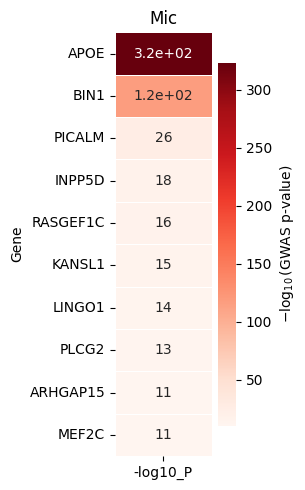

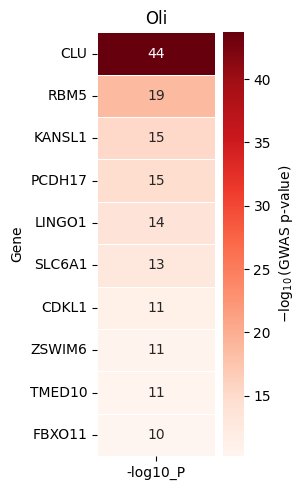

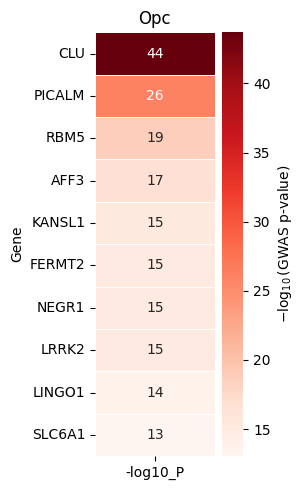

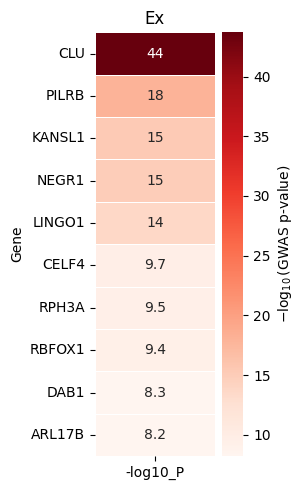

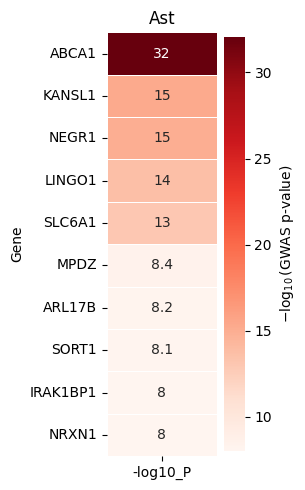

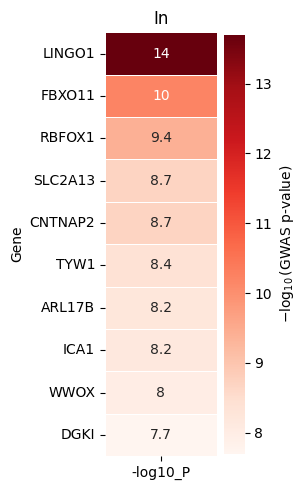

In [10]:
# snp gwas overlap heatmapts

import pandas as pd

import os
import joblib
from collections import defaultdict

# Define base path and cell types
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Opc': 'Oligodendrocyte Progenitor Cells',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# Dictionary to hold final predictors
predictive_genes_dict = {}

for cell_type in cell_types:
    print(f"Processing: {cell_type}")
    gene_presence = defaultdict(int)

    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue

        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_

        for gene, imp in zip(feature_names, importances):
            gene_lower = gene.lower()
            if imp > 0 and not (
                gene_lower.startswith("age_death")
                or gene_lower.startswith("msex")
                or gene_lower.startswith("apoe_geno")
                or gene_lower.startswith("educ")
            ):
                gene_presence[gene] += 1

        # for gene, imp in zip(feature_names, importances):
        #     if imp > 0:
        #         gene_presence[gene] += 1

    # Keep genes that are non-zero in ≥ 3 splits
    final_predictors = [gene for gene, count in gene_presence.items() if count >= 2]
    predictive_genes_dict[cell_type] = final_predictors
    print(f"{cell_type}: {len(final_predictors)} predictive genes")

# This dictionary can now be used as your new top_25_dict equivalent
top_25_features_dict = predictive_genes_dict

# --- Load GWAS genes ---
gwas_path = '/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv'
gwas_df = pd.read_csv(gwas_path, sep='\t', low_memory=False)

# Extract GWAS genes as uppercase
gwas_genes = set()
for genes in gwas_df['mappedGenes'].dropna():
    for g in genes.split(','):
        gwas_genes.add(g.strip().upper())

# --- Check overlap per cell type ---
gwas_overlap_dict = {}

for cell_type, pred_genes in predictive_genes_dict.items():
    pred_genes_upper = set(g.upper() for g in pred_genes)
    
    # Exact overlap
    overlap = pred_genes_upper & gwas_genes

    # Manual exception: include RASGEF1B if RASGEF1C in GWAS
    if "RASGEF1B" in pred_genes_upper and "RASGEF1B" in gwas_genes:
        overlap.add("RASGEF1B")

    gwas_overlap_dict[cell_type] = sorted(list(overlap))
    print(f"{cell_type}: {len(overlap)} genes overlap with GWAS (exact match + RASGEF1B manual inclusion)")
    print(overlap)

# --- Save CSV for supplement ---
all_types = []
for cell_type, overlap_genes in gwas_overlap_dict.items():
    for gene in overlap_genes:
        all_types.append({'CellType': cell_type, 'Gene': gene})

pd.DataFrame(all_types).to_csv('/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/GWAS/AD_predictive_genes_GWAS_overlap_exact.csv', index=False)

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load overlap info
overlap_df = pd.read_csv('/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/GWAS/AD_predictive_genes_GWAS_overlap_exact.csv')
overlap_genes = set(overlap_df['Gene'].str.upper())

# Load GWAS data
gwas_path = '/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv'
gwas_df = pd.read_csv(gwas_path, sep='\t', low_memory=False)

# Create GWAS gene set
gwas_gene_set = set(
    g.strip().upper()
    for genes in gwas_df['mappedGenes'].dropna()
    for g in genes.split(',')
)

# Add RASGEF1C if needed
if "RASGEF1B" in overlap_genes and "RASGEF1B" in gwas_gene_set:
    print("Adding RASGEF1C manually to overlap genes.")
    overlap_genes.add("RASGEF1B")

gw_sig_thr = 5e-8
N = 10  # Top N genes per cell type

rows = []
for _, row in gwas_df.iterrows():
    pval = float(row['pValue']) if row['pValue'] != 'NR' else None
    loc = row['locations']
    genes = [g.strip().upper() for g in str(row['mappedGenes']).split(',') if g]
    
    for gene in genes:
        if gene in overlap_genes and pval is not None and pval > 0:
            cell_type_list = overlap_df.loc[overlap_df['Gene'].str.upper() == gene, 'CellType'].unique()
            # If RASGEF1C was not in overlap_df originally, assign all cell types where RASGEF1B was present
            if len(cell_type_list) == 0 and gene == "RASGEF1B":
                cell_type_list = overlap_df.loc[overlap_df['Gene'].str.upper() == "RASGEF1B", 'CellType'].unique()
            
            for cell_type in cell_type_list:
                rows.append({
                    'Gene': gene,
                    'CellType': cell_type,
                    'GWAS_P': pval,
                    '-log10_P': -np.log10(pval)
                })

df_plot = pd.DataFrame(rows)

# Deduplicate: keep only the lowest p-value per (Gene, CellType)
df_plot = df_plot.sort_values('GWAS_P').drop_duplicates(subset=['Gene', 'CellType'], keep='first')

# --- Plot separate heatmaps per cell type ---
for cell_type in df_plot['CellType'].unique():
    sub = df_plot[df_plot['CellType'] == cell_type]
    
    # Take top N significant genes
    top_sub = sub[sub['GWAS_P'] < gw_sig_thr].sort_values('GWAS_P').head(N)
    
    if top_sub.empty:
        print(f"Skipping {cell_type}: no significant genes.")
        continue

    # Create DataFrame for heatmap
    heatmap_df = top_sub[['Gene', '-log10_P']].set_index('Gene')
    heatmap_df = heatmap_df.sort_values('-log10_P', ascending=False)

    plt.figure(figsize=(3, max(4, 0.5 * len(heatmap_df))))
    sns.heatmap(
        heatmap_df,
        annot=True,
        cmap='Reds',
        cbar_kws={'label': r'$-\log_{10}$(GWAS p-value)'},
        linewidths=0.5
    )
    plt.title(f"{cell_type}")
    plt.ylabel("Gene")
    plt.xlabel("")
    plt.tight_layout()
    plt.savefig(f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure10/heatmap_{cell_type}_top{N}.png", dpi=300)
    plt.show()


In [3]:
import os
import joblib
import pandas as pd
from collections import defaultdict

def get_gwas_overlap_dict(base_dir, gwas_path, cell_types):
    """Return dict of GWAS-overlapping predictive genes per cell type."""
    
    predictive_genes_dict = {}

    for cell_type in cell_types:
        gene_presence = defaultdict(int)

        for split in range(1, 6):
            joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
            if not os.path.exists(joblib_path):
                continue

            model = joblib.load(joblib_path)
            feature_names = model.feature_names_in_
            importances = model.feature_importances_

            for gene, imp in zip(feature_names, importances):
                gene_lower = gene.lower()
                if imp > 0 and not (
                    gene_lower.startswith("age_death")
                    or gene_lower.startswith("msex")
                    or gene_lower.startswith("apoe_geno")
                    or gene_lower.startswith("educ")
                ):
                    gene_presence[gene] += 1

        # Keep genes present in ≥ 2 splits
        final_predictors = [gene for gene, count in gene_presence.items() if count >= 2]
        predictive_genes_dict[cell_type] = final_predictors

    # Load GWAS genes
    gwas_df = pd.read_csv(gwas_path, sep='\t', low_memory=False)
    gwas_genes = set()
    for genes in gwas_df['mappedGenes'].dropna():
        for g in genes.split(','):
            gwas_genes.add(g.strip().upper())

    # Match predictors with GWAS hits
    gwas_overlap_dict = {}
    for cell_type, pred_genes in predictive_genes_dict.items():
        pred_genes_upper = set(g.upper() for g in pred_genes)
        overlap = pred_genes_upper & gwas_genes

        # Manual inclusion for RASGEF1B if RASGEF1C is in GWAS
        if "RASGEF1B" in pred_genes_upper and "RASGEF1C" in gwas_genes:
            overlap.add("RASGEF1B")

        gwas_overlap_dict[cell_type] = sorted(overlap)

    return gwas_overlap_dict

# === Define paths ===
gwas_path = '/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv'

# Directories containing saved joblib models
cerad_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
ad_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"

# Short cell type keys
cell_types = ['Ast', 'Mic', 'In', 'Oli', 'Opc', 'Ex']

# Build dictionaries
cerad_gwas_overlap_dict = get_gwas_overlap_dict(cerad_dir, gwas_path, cell_types)
ad_gwas_overlap_dict = get_gwas_overlap_dict(ad_dir, gwas_path, cell_types)

/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w


=== Microglia ===
Shared (35): APOE, ARL17B, ATP8B4, AVL9, CACNA1A, CELF2, CPM, DLG2, DOCK4, EIF4G3, EXOC4, FOXP1, FRMD4B, HDAC9, INPP5D, JAZF1, L3MBTL4, LINGO1, MEF2C, MTMR3, PARP8, PDE4B, PDE8A, PICALM, QKI, RASGEF1B, SMARCA2, SNX9, ST6GAL1, TANC2, TET2, TLN2, TMEM163, TOP1, ZSWIM6
CERAD only (25): ABHD12, AKAP10, ALCAM, ARHGAP24, CELF1, CENPP, CHD2, CHN2, CHSY3, ITSN2, MACROD2, MKLN1, MTHFD1L, PSD3, RNF130, SCAPER, SETX, SIPA1L2, SLMAP, SORL1, SRGAP3, STK3, TBXAS1, USP3, WDPCP
AD only (34): ADGRB3, AFF1, APBA1, ARHGAP15, ATM, BIN1, CEP170, CTNNA1, CTSB, DENND3, DENND4A, DSCAM, DST, ELMO1, ERC2, FOXP2, GAB2, IKZF1, IQGAP2, KANSL1, MAP4K4, NFAT5, NPC1, PLCG2, RAB1A, RAP1A, RASGEF1C, RBFOX1, RIN3, SDK1, SPG11, SREBF2, TRPS1, ZBTB16

=== Oligodendrocytes ===
Shared (57): ABCA8, ACER3, AGAP1, AKAP6, ANO4, ARL17B, CNTNAP4, CTNND2, DCC, DLC1, DLG2, DMD, DST, DYSF, ELMO1, ERBB4, FOXN2, FOXP1, GALNT13, GRM3, ITPKB, ITSN2, KCNH8, KLHL4, LAMP1, LINGO1, LRP1B, MAP4K4, NECAB1, NKAIN2, NRXN3, NT

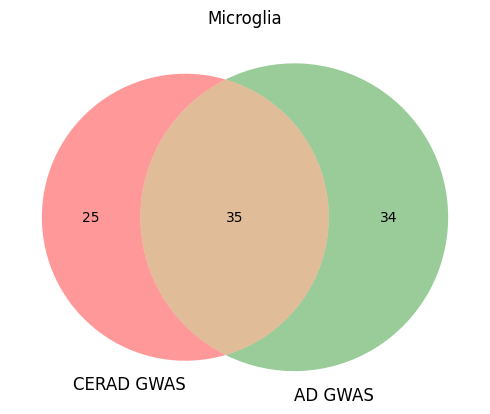

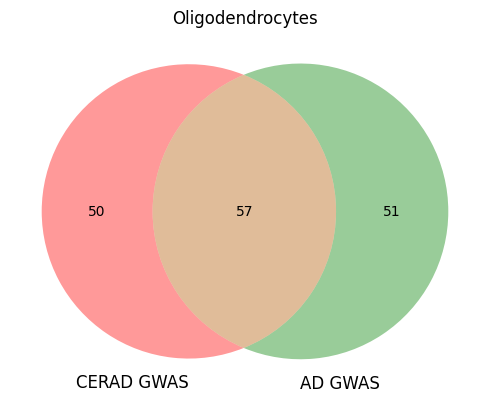

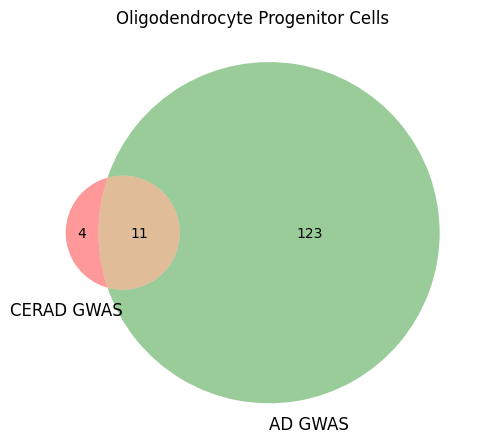

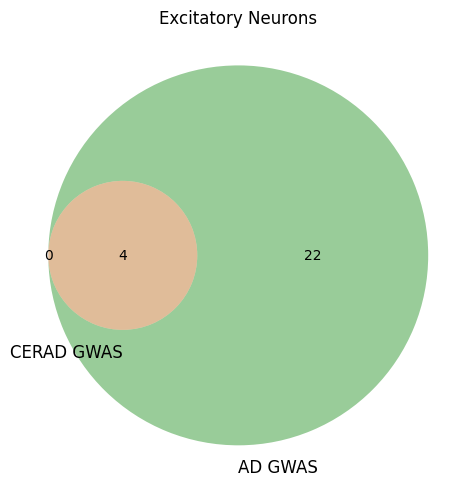

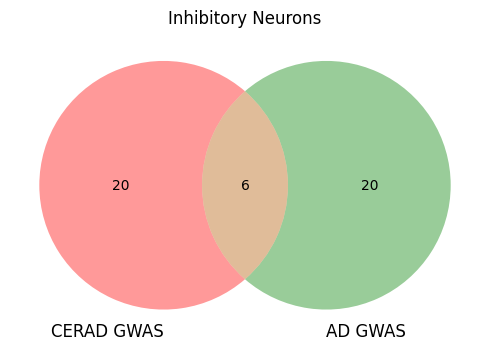

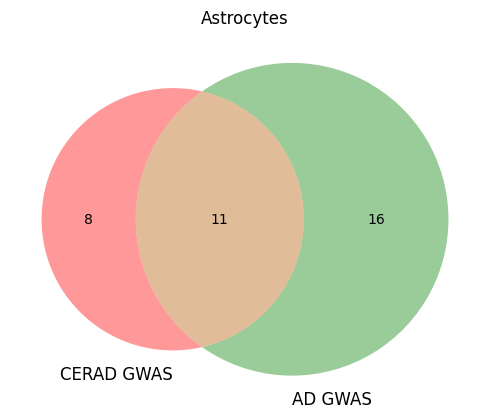

In [35]:
from collections import defaultdict
import pandas as pd

# Define shared cell type label mapping (adjust if needed)
ct_labels = {
    'Mic': 'Microglia',
    'Oli': 'Oligodendrocytes',
    'Ex': 'Excitatory Neurons',
    'In': 'Inhibitory Neurons',
    'Ast': 'Astrocytes',
    'Opc': 'Oligodendrocyte Progenitor Cells'
}

# Build overlap summaries
rows = []

for ct_key in ct_labels:
    cerad_genes = set(g.upper() for g in cerad_gwas_overlap_dict.get(ct_key, []))
    ad_genes = set(g.upper() for g in ad_gwas_overlap_dict.get(ct_key, []))
    
    shared = cerad_genes & ad_genes
    cerad_only = cerad_genes - ad_genes
    ad_only = ad_genes - cerad_genes

    rows.append({
        "CellType": ct_labels[ct_key],
        "CERAD_only_count": len(cerad_only),
        "AD_only_count": len(ad_only),
        "Shared_count": len(shared),
        "CERAD_only_genes": ", ".join(sorted(cerad_only)),
        "AD_only_genes": ", ".join(sorted(ad_only)),
        "Shared_genes": ", ".join(sorted(shared))
    })

overlap_df = pd.DataFrame(rows)


overlap_df.to_csv("GWAS_overlap_AD_vs_CERAD_by_celltype.csv", index=False)

# Optional: print gene sets per cell type
for i, row in overlap_df.iterrows():
    print(f"\n=== {row['CellType']} ===")
    print(f"Shared ({row['Shared_count']}): {row['Shared_genes']}")
    print(f"CERAD only ({row['CERAD_only_count']}): {row['CERAD_only_genes']}")
    print(f"AD only ({row['AD_only_count']}): {row['AD_only_genes']}")


from matplotlib_venn import venn2
import matplotlib.pyplot as plt

for ct_key in ['Mic', 'Oli', 'Opc', 'Ex', 'In', 'Ast']:
    cerad = set(cerad_gwas_overlap_dict.get(ct_key, []))
    ad = set(ad_gwas_overlap_dict.get(ct_key, []))

    plt.figure(figsize=(5, 5))
    venn2([cerad, ad], set_labels=("CERAD GWAS", "AD GWAS"))
    plt.title(ct_labels[ct_key])
    plt.tight_layout()
    plt.savefig(f"venn_{ct_labels[ct_key]}.png", dpi=300)
    plt.show()

In [36]:
# Load GWAS file
gwas_path = '/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv'
gwas_df = pd.read_csv(gwas_path, sep='\t', low_memory=False)

# Clean p-values and map genes to min p-value
gene_to_pval = defaultdict(list)

for _, row in gwas_df.iterrows():
    if row['pValue'] == 'NR':
        continue
    try:
        pval = float(row['pValue'])
    except:
        continue
    genes = str(row['mappedGenes']).split(',')
    for g in genes:
        gene = g.strip().upper()
        if gene:
            gene_to_pval[gene].append(pval)

# Convert to min-pval mapping
gene_to_minp = {gene: min(pvals) for gene, pvals in gene_to_pval.items()}


rows = []

for ct_key in ct_labels:
    cerad_genes = set(g.upper() for g in cerad_gwas_overlap_dict.get(ct_key, []))
    ad_genes = set(g.upper() for g in ad_gwas_overlap_dict.get(ct_key, []))
    
    shared = cerad_genes & ad_genes
    cerad_only = cerad_genes - ad_genes
    ad_only = ad_genes - cerad_genes

    def top5(geneset):
        genes_with_pval = [(g, gene_to_minp.get(g, 1.0)) for g in geneset]
        sorted_genes = sorted(genes_with_pval, key=lambda x: x[1])
        return [f"{g} (p={p:.1e})" for g, p in sorted_genes[:5]]

    rows.append({
        "CellType": ct_labels[ct_key],
        "CERAD_only_count": len(cerad_only),
        "AD_only_count": len(ad_only),
        "Shared_count": len(shared),
        "CERAD_only_genes": ", ".join(sorted(cerad_only)),
        "AD_only_genes": ", ".join(sorted(ad_only)),
        "Shared_genes": ", ".join(sorted(shared)),
        "Top5_CERAD_only": "; ".join(top5(cerad_only)),
        "Top5_AD_only": "; ".join(top5(ad_only)),
        "Top5_Shared": "; ".join(top5(shared))
    })

overlap_df = pd.DataFrame(rows)


overlap_df.to_csv("GWAS_overlap_AD_vs_CERAD_by_celltype.csv", index=False)

for i, row in overlap_df.iterrows():
    print(f"\n=== {row['CellType']} ===")
    print(f"Shared ({row['Shared_count']}): Top 5 → {row['Top5_Shared']}")
    print(f"CERAD only ({row['CERAD_only_count']}): Top 5 → {row['Top5_CERAD_only']}")
    print(f"AD only ({row['AD_only_count']}): Top 5 → {row['Top5_AD_only']}")


=== Microglia ===
Shared (35): Top 5 → APOE (p=0.0e+00); PICALM (p=1.0e-26); INPP5D (p=1.0e-18); LINGO1 (p=2.0e-14); MEF2C (p=2.0e-11)
CERAD only (25): Top 5 → SCAPER (p=5.0e-23); SORL1 (p=1.0e-21); USP3 (p=2.0e-16); AKAP10 (p=1.0e-12); TBXAS1 (p=8.0e-12)
AD only (34): Top 5 → BIN1 (p=6.0e-118); RASGEF1C (p=2.0e-16); KANSL1 (p=5.0e-16); PLCG2 (p=1.0e-13); ARHGAP15 (p=1.0e-11)

=== Oligodendrocytes ===
Shared (57): Top 5 → LINGO1 (p=2.0e-14); SLC6A1 (p=9.0e-14); ZSWIM6 (p=2.0e-11); TMED10 (p=3.0e-11); PHF3 (p=1.0e-10)
CERAD only (50): Top 5 → BIN1 (p=6.0e-118); MOG (p=5.0e-18); ANK3 (p=3.0e-13); APP (p=1.0e-12); BCAS3 (p=1.0e-11)
AD only (51): Top 5 → CLU (p=2.0e-44); RBM5 (p=2.0e-19); KANSL1 (p=5.0e-16); PCDH17 (p=2.0e-15); CDKL1 (p=5.0e-12)

=== Excitatory Neurons ===
Shared (4): Top 5 → LINGO1 (p=2.0e-14); TENM2 (p=4.0e-08); CADPS2 (p=8.0e-07); RASGEF1B (p=1.0e+00)
CERAD only (0): Top 5 → 
AD only (22): Top 5 → CLU (p=2.0e-44); PILRB (p=1.0e-18); KANSL1 (p=5.0e-16); NEGR1 (p=1.0e-15

/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.5.1 w


=== Microglia ===
Shared (35): Top 5 → APOE (p=0.0e+00); PICALM (p=1.0e-26); INPP5D (p=1.0e-18); LINGO1 (p=2.0e-14); MEF2C (p=2.0e-11)
CERAD only (25): Top 5 → SCAPER (p=5.0e-23); SORL1 (p=1.0e-21); USP3 (p=2.0e-16); AKAP10 (p=1.0e-12); TBXAS1 (p=8.0e-12)
AD only (34): Top 5 → BIN1 (p=6.0e-118); RASGEF1C (p=2.0e-16); KANSL1 (p=5.0e-16); PLCG2 (p=1.0e-13); ARHGAP15 (p=1.0e-11)

=== Oligodendrocytes ===
Shared (57): Top 5 → LINGO1 (p=2.0e-14); SLC6A1 (p=9.0e-14); ZSWIM6 (p=2.0e-11); TMED10 (p=3.0e-11); PHF3 (p=1.0e-10)
CERAD only (50): Top 5 → BIN1 (p=6.0e-118); MOG (p=5.0e-18); ANK3 (p=3.0e-13); APP (p=1.0e-12); BCAS3 (p=1.0e-11)
AD only (51): Top 5 → CLU (p=2.0e-44); RBM5 (p=2.0e-19); KANSL1 (p=5.0e-16); PCDH17 (p=2.0e-15); CDKL1 (p=5.0e-12)

=== Excitatory Neurons ===
Shared (4): Top 5 → LINGO1 (p=2.0e-14); TENM2 (p=4.0e-08); CADPS2 (p=8.0e-07); RASGEF1B (p=1.0e+00)
CERAD only (0): Top 5 → 
AD only (22): Top 5 → CLU (p=2.0e-44); PILRB (p=1.0e-18); KANSL1 (p=5.0e-16); NEGR1 (p=1.0e-15

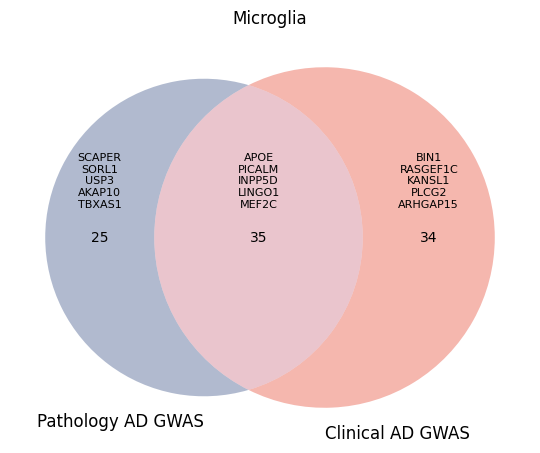

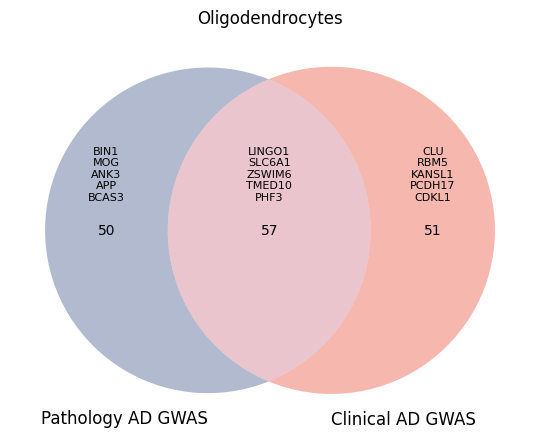

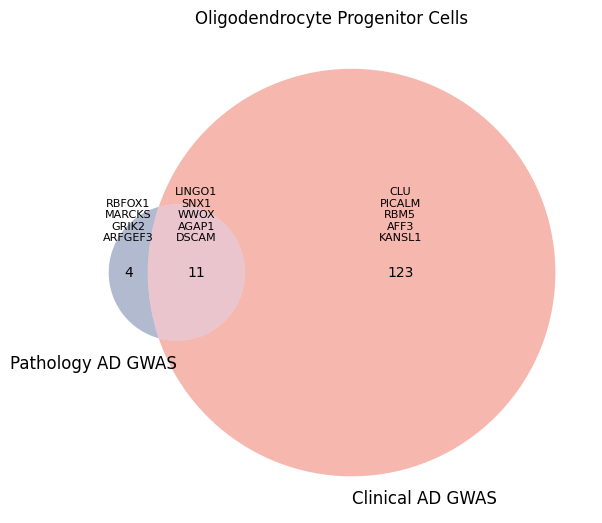

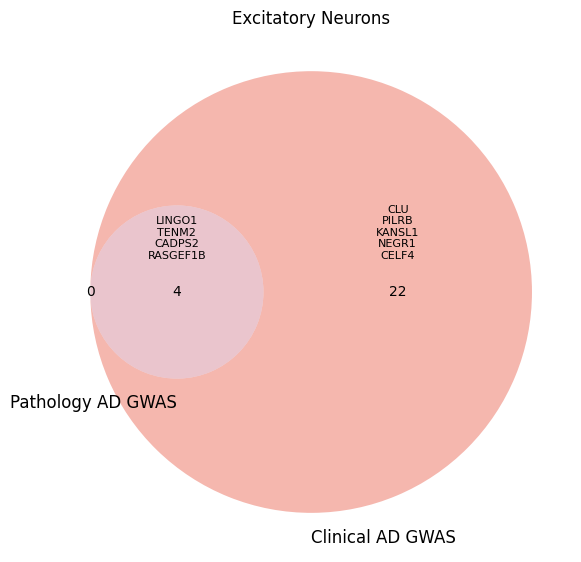

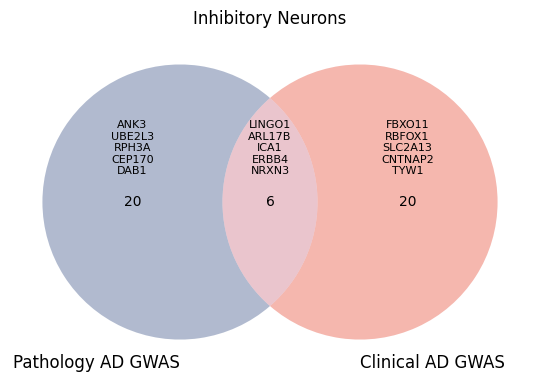

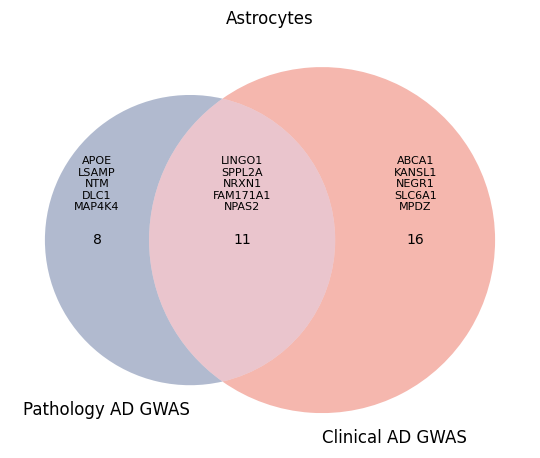

In [44]:
import os
import joblib
import pandas as pd
from collections import defaultdict

def get_gwas_overlap_dict(base_dir, gwas_path, cell_types):
    """Return dict of GWAS-overlapping predictive genes per cell type."""
    
    predictive_genes_dict = {}

    for cell_type in cell_types:
        gene_presence = defaultdict(int)

        for split in range(1, 6):
            joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
            if not os.path.exists(joblib_path):
                continue

            model = joblib.load(joblib_path)
            feature_names = model.feature_names_in_
            importances = model.feature_importances_

            for gene, imp in zip(feature_names, importances):
                gene_lower = gene.lower()
                if imp > 0 and not (
                    gene_lower.startswith("age_death")
                    or gene_lower.startswith("msex")
                    or gene_lower.startswith("apoe_geno")
                    or gene_lower.startswith("educ")
                ):
                    gene_presence[gene] += 1

        # Keep genes present in ≥ 2 splits
        final_predictors = [gene for gene, count in gene_presence.items() if count >= 2]
        predictive_genes_dict[cell_type] = final_predictors

    # Load GWAS genes
    gwas_df = pd.read_csv(gwas_path, sep='\t', low_memory=False)
    gwas_genes = set()
    for genes in gwas_df['mappedGenes'].dropna():
        for g in genes.split(','):
            gwas_genes.add(g.strip().upper())

    # Match predictors with GWAS hits
    gwas_overlap_dict = {}
    for cell_type, pred_genes in predictive_genes_dict.items():
        pred_genes_upper = set(g.upper() for g in pred_genes)
        overlap = pred_genes_upper & gwas_genes

        # Manual inclusion for RASGEF1B if RASGEF1C is in GWAS
        if "RASGEF1B" in pred_genes_upper and "RASGEF1C" in gwas_genes:
            overlap.add("RASGEF1B")

        gwas_overlap_dict[cell_type] = sorted(overlap)

    return gwas_overlap_dict

# === Define paths ===
gwas_path = '/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv'

# Directories containing saved joblib models
cerad_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_cerad"
ad_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"

# Short cell type keys
cell_types = ['Ast', 'Mic', 'In', 'Oli', 'Opc', 'Ex']

# Build dictionaries
cerad_gwas_overlap_dict = get_gwas_overlap_dict(cerad_dir, gwas_path, cell_types)
ad_gwas_overlap_dict = get_gwas_overlap_dict(ad_dir, gwas_path, cell_types)

# Load GWAS file
gwas_path = '/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv'
gwas_df = pd.read_csv(gwas_path, sep='\t', low_memory=False)

# Clean p-values and map genes to min p-value
gene_to_pval = defaultdict(list)

for _, row in gwas_df.iterrows():
    if row['pValue'] == 'NR':
        continue
    try:
        pval = float(row['pValue'])
    except:
        continue
    genes = str(row['mappedGenes']).split(',')
    for g in genes:
        gene = g.strip().upper()
        if gene:
            gene_to_pval[gene].append(pval)

# Convert to min-pval mapping
gene_to_minp = {gene: min(pvals) for gene, pvals in gene_to_pval.items()}


rows = []

for ct_key in ct_labels:
    cerad_genes = set(g.upper() for g in cerad_gwas_overlap_dict.get(ct_key, []))
    ad_genes = set(g.upper() for g in ad_gwas_overlap_dict.get(ct_key, []))
    
    shared = cerad_genes & ad_genes
    cerad_only = cerad_genes - ad_genes
    ad_only = ad_genes - cerad_genes

    def top5(geneset):
        genes_with_pval = [(g, gene_to_minp.get(g, 1.0)) for g in geneset]
        sorted_genes = sorted(genes_with_pval, key=lambda x: x[1])
        return [f"{g} (p={p:.1e})" for g, p in sorted_genes[:5]]

    rows.append({
        "CellType": ct_labels[ct_key],
        "CERAD_only_count": len(cerad_only),
        "AD_only_count": len(ad_only),
        "Shared_count": len(shared),
        "CERAD_only_genes": ", ".join(sorted(cerad_only)),
        "AD_only_genes": ", ".join(sorted(ad_only)),
        "Shared_genes": ", ".join(sorted(shared)),
        "Top5_CERAD_only": "; ".join(top5(cerad_only)),
        "Top5_AD_only": "; ".join(top5(ad_only)),
        "Top5_Shared": "; ".join(top5(shared))
    })

overlap_df = pd.DataFrame(rows)


overlap_df.to_csv("GWAS_overlap_AD_vs_CERAD_by_celltype.csv", index=False)

for i, row in overlap_df.iterrows():
    print(f"\n=== {row['CellType']} ===")
    print(f"Shared ({row['Shared_count']}): Top 5 → {row['Top5_Shared']}")
    print(f"CERAD only ({row['CERAD_only_count']}): Top 5 → {row['Top5_CERAD_only']}")
    print(f"AD only ({row['AD_only_count']}): Top 5 → {row['Top5_AD_only']}")


from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict

# === Load GWAS p-values ===
gwas_path = '/n/scratch/users/a/adm808/MONDO_0004975_associations_export.tsv'
gwas_df = pd.read_csv(gwas_path, sep='\t', low_memory=False)

gene_to_pval = defaultdict(list)
for _, row in gwas_df.iterrows():
    if row['pValue'] == 'NR':
        continue
    try:
        pval = float(row['pValue'])
    except:
        continue
    for g in str(row['mappedGenes']).split(','):
        gene = g.strip().upper()
        if gene:
            gene_to_pval[gene].append(pval)

gene_to_minp = {g: min(pvals) for g, pvals in gene_to_pval.items()}

# === Generate annotated Venn diagrams ===
for ct_key in ['Mic', 'Oli', 'Opc', 'Ex', 'In', 'Ast']:
    ct_name = ct_labels[ct_key]
    
    cerad_set = set(g.upper() for g in cerad_gwas_overlap_dict.get(ct_key, []))
    ad_set = set(g.upper() for g in ad_gwas_overlap_dict.get(ct_key, []))
    
    shared = cerad_set & ad_set
    cerad_only = cerad_set - ad_set
    ad_only = ad_set - cerad_set

    if not (cerad_only or ad_only or shared):
        print(f"[SKIP] {ct_name} has no overlap to plot.")
        continue

    def top5(geneset):
        genes_with_pval = [(g, gene_to_minp.get(g, 1.0)) for g in geneset]
        sorted_genes = sorted(genes_with_pval, key=lambda x: x[1])
        return [f"{g}" for g, _ in sorted_genes[:5]]

    top_cerad = top5(cerad_only)
    top_ad = top5(ad_only)
    top_shared = top5(shared)

    subset_sizes = (len(cerad_only), len(ad_only), len(shared))

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    v = venn2(subsets=subset_sizes, set_labels=("Pathology AD GWAS", "Clinical AD GWAS"), set_colors = ["#3C5488", "#E64B35"], ax=ax)
    ax.set_title(f"{ct_name}")

    region_texts = {
        '10': top_cerad,
        '01': top_ad,
        '11': top_shared
    }

    for region_id, genes in region_texts.items():
        label = v.get_label_by_id(region_id)
        if genes and label:
            x, y = label.get_position()
            ax.text(x, y + 0.08, '\n'.join(genes), fontsize=8, ha='center', va='bottom')

    # Lock margins to ensure fixed-size layout
    fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
    fig.savefig(f"/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Figure3/GWAS/venn_{ct_name}_annotated.png", dpi=300, bbox_inches='tight')
    plt.show(fig)